# I. Importing Necessary Things for data cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# II. Investigating the Dataset

In [3]:
df = pd.read_csv('US_Crime_DataSet.csv')
df

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638449,638450,WY01500,Park County,Sheriff,Park,Wyoming,2014,January,1,Murder or Manslaughter,...,Hispanic,Unknown,0,Unknown,Unknown,Unknown,Handgun,0,0,FBI
638450,638451,WY01700,Sheridan County,Sheriff,Sheridan,Wyoming,2014,June,1,Murder or Manslaughter,...,Unknown,Male,57,White,Unknown,Acquaintance,Handgun,0,0,FBI
638451,638452,WY01701,Sheridan,Municipal Police,Sheridan,Wyoming,2014,September,1,Murder or Manslaughter,...,Unknown,Female,22,Asian/Pacific Islander,Unknown,Daughter,Suffocation,0,0,FBI
638452,638453,WY01800,Sublette County,Sheriff,Sublette,Wyoming,2014,December,1,Murder or Manslaughter,...,Not Hispanic,Male,31,White,Not Hispanic,Stranger,Knife,0,1,FBI


In [4]:
for columns in df.columns:
    print (f'---------- {columns}----------' )
    print (df[columns].unique())

---------- Record ID----------
[     1      2      3 ... 638452 638453 638454]
---------- Agency Code----------
['AK00101' 'AK00103' 'AK00106' ... 'WA01750' 'WA02705' 'WVWSP65']
---------- Agency Name----------
['Anchorage' 'Juneau' 'Nome' ... 'Sp: Hundred' 'Sheridan County'
 'Sublette County']
---------- Agency Type----------
['Municipal Police' 'County Police' 'State Police' 'Sheriff'
 'Special Police' 'Regional Police' 'Tribal Police']
---------- City----------
['Anchorage' 'Juneau' 'Nome' ... 'Rooks' 'McCone' 'Antelope']
---------- State----------
['Alaska' 'Alabama' 'Arkansas' 'Arizona' 'California' 'Colorado'
 'Connecticut' 'District of Columbia' 'Delaware' 'Florida' 'Georgia'
 'Hawaii' 'Iowa' 'Idaho' 'Illinois' 'Indiana' 'Kansas' 'Kentucky'
 'Louisiana' 'Massachusetts' 'Maryland' 'Maine' 'Michigan' 'Minnesota'
 'Missouri' 'Mississippi' 'Montana' 'Nebraska' 'North Carolina'
 'North Dakota' 'New Hampshire' 'New Jersey' 'New Mexico' 'Nevada'
 'New York' 'Ohio' 'Oklahoma' 'Oregon' '

In [5]:
duplicated = df[df.duplicated()]
duplicated

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source


df.info()

In [12]:
df.isna().sum()

Record ID                0
Agency Code              0
Agency Name              0
Agency Type              0
City                     0
State                    0
Year                     0
Month                    0
Incident                 0
Crime Type               0
Crime Solved             0
Victim Sex               0
Victim Age               0
Victim Race              0
Victim Ethnicity         0
Perpetrator Sex          0
Perpetrator Age          0
Perpetrator Race         0
Perpetrator Ethnicity    0
Relationship             0
Weapon                   0
Victim Count             0
Perpetrator Count        0
Record Source            0
dtype: int64

# III. Data Cleaning scenario na

We got to think thoroughly on how to clean data, how to visualize the target data to be shown, and Feed it to the unsupervise learning model we are gonna use for predictions.

In [6]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape:
(638454, 24)

Columns:
['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Perpetrator Sex', 'Perpetrator Age', 'Perpetrator Race', 'Perpetrator Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count', 'Record Source']

Data types:
Record ID                 int64
Agency Code              object
Agency Name              object
Agency Type              object
City                     object
State                    object
Year                      int64
Month                    object
Incident                  int64
Crime Type               object
Crime Solved             object
Victim Sex               object
Victim Age                int64
Victim Race              object
Victim Ethnicity         object
Perpetrator Sex          object
Perpetrator Age          object
Perpetrator Race         object
Perpetrator Ethnicit

The Dataset itself is already clean so no need for further cleaning.

# Data Checking and analyzing

In [13]:
categorical_cols = [
    'Agency Type',
    'State',
    'Crime Type',
    'Crime Solved',
    'Victim Sex',
    'Victim Race',
    'Victim Ethnicity',
    'Perpetrator Sex',
    'Perpetrator Race',
    'Perpetrator Ethnicity',
    'Relationship',
    'Weapon',
    'Record Source'
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(15))


Agency Type
Unique values: 7
Agency Type
Municipal Police    493026
Sheriff             105322
County Police        22693
State Police         14235
Special Police        2889
Regional Police        235
Tribal Police           54
Name: count, dtype: int64

State
Unique values: 51
State
California        99783
Texas             62095
New York          49268
Florida           37164
Michigan          28448
Illinois          25871
Pennsylvania      24236
Georgia           21088
North Carolina    20390
Louisiana         19629
Ohio              19158
Maryland          17312
Virginia          15520
Tennessee         14930
Missouri          14832
Name: count, dtype: int64

Crime Type
Unique values: 2
Crime Type
Murder or Manslaughter        629338
Manslaughter by Negligence      9116
Name: count, dtype: int64

Crime Solved
Unique values: 2
Crime Solved
Yes    448172
No     190282
Name: count, dtype: int64

Victim Sex
Unique values: 3
Victim Sex
Male       494125
Female     143345
Unknown     

In [9]:
numeric_cols = [
    'Year',
    'Incident',
    'Victim Age',
    'Victim Count',
    'Perpetrator Count'
]

print(df[numeric_cols].describe())

                Year       Incident     Victim Age   Victim Count  \
count  638454.000000  638454.000000  638454.000000  638454.000000   
mean     1995.801102      22.967924      35.033512       0.123334   
std         9.927693      92.149821      41.628306       0.537733   
min      1980.000000       0.000000       0.000000       0.000000   
25%      1987.000000       1.000000      22.000000       0.000000   
50%      1995.000000       2.000000      30.000000       0.000000   
75%      2004.000000      10.000000      42.000000       0.000000   
max      2014.000000     999.000000     998.000000      10.000000   

       Perpetrator Count  
count      638454.000000  
mean            0.185224  
std             0.585496  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%             0.000000  
max            10.000000  


In [10]:
print(df['Perpetrator Age'].value_counts().head(30))
print("\nUnique values:", df['Perpetrator Age'].nunique())

Perpetrator Age
0     211079
20     21158
19     19807
21     18509
18     18477
22     17977
23     17168
25     17157
24     15964
26     14347
17     13945
27     13825
30     13304
28     13126
29     12163
31     10660
32     10530
33      9639
35      9423
16      9269
34      9037
36      8033
37      7764
38      7156
39      6840
40      6799
41      5989
42      5713
15      5360
43      5306
Name: count, dtype: int64

Unique values: 191


### Investigating Special Values

In [14]:
print("Victim Age values:")
print(df['Victim Age'].value_counts().sort_index().head(20))

print("\nHighest Victim Age values:")
print(df['Victim Age'].value_counts().sort_index().tail(20))


print("Perpetrator Age data type:")
print(df['Perpetrator Age'].dtype)

print("\nMost common values:")
print(df['Perpetrator Age'].value_counts().head(30))

print("\nUnique values:")
print(df['Perpetrator Age'].nunique())

print("\nIncident values:")
print(df['Incident'].value_counts().sort_index().head(20))

print("\nHighest Incident values:")
print(df['Incident'].value_counts().sort_index().tail(20))


print("\nVictim Count:")
print(df['Victim Count'].value_counts().sort_index())


print("\nPerpetrator Count:")
print(df['Perpetrator Count'].value_counts().sort_index())

Victim Age values:
Victim Age
0      8444
1      5525
2      3805
3      2378
4      1659
5      1194
6       999
7       915
8       852
9       834
10      854
11      911
12     1239
13     1897
14     3342
15     5905
16     9402
17    14030
18    18469
19    21939
Name: count, dtype: int64

Highest Victim Age values:
Victim Age
81      930
82      835
83      765
84      686
85      627
86      574
87      460
88      408
89      313
90      281
91      215
92      156
93      134
94      116
95       82
96       37
97       39
98       33
99     9281
998     974
Name: count, dtype: int64
Perpetrator Age data type:
object

Most common values:
Perpetrator Age
0     211079
20     21158
19     19807
21     18509
18     18477
22     17977
23     17168
25     17157
24     15964
26     14347
17     13945
27     13825
30     13304
28     13126
29     12163
31     10660
32     10530
33      9639
35      9423
16      9269
34      9037
36      8033
37      7764
38      7156
39      6840
40 

In [12]:
print(df['Month'].value_counts())

Month
July         58696
August       58072
December     55187
September    54117
June         53662
October      53650
May          53394
January      52928
March        51444
April        51209
November     50016
February     46079
Name: count, dtype: int64


In [15]:
perp_age_numeric = pd.to_numeric(df['Perpetrator Age'], errors='coerce')

print("Non-numeric values:")
print(df.loc[perp_age_numeric.isna(), 'Perpetrator Age'].value_counts())

print("\nPerpetrator Age distribution:")
print(perp_age_numeric.value_counts().sort_index().head(20))

print("\nHighest Perpetrator Age values:")
print(perp_age_numeric.value_counts().sort_index().tail(20))

Non-numeric values:
Perpetrator Age
    1
Name: count, dtype: int64

Perpetrator Age distribution:
Perpetrator Age
0.0     216327
1.0         34
2.0          6
3.0         24
4.0         29
5.0         33
6.0         50
7.0         48
8.0         62
9.0         86
10.0       145
11.0       227
12.0       487
13.0      1109
14.0      2567
15.0      5441
16.0      9423
17.0     14196
18.0     18834
19.0     20250
Name: count, dtype: int64

Highest Perpetrator Age values:
Perpetrator Age
80.0    252
81.0    228
82.0    206
83.0    168
84.0    141
85.0    139
86.0    103
87.0    113
88.0     85
89.0     56
90.0     58
91.0     33
92.0     32
93.0     17
94.0     10
95.0      9
96.0      7
97.0      3
98.0      7
99.0     90
Name: count, dtype: int64


# investigate the special age codes

In [16]:
print("=== VICTIM AGE ===")
print(df['Victim Age'].value_counts().loc[
    lambda x: x.index.isin([0, 99, 998])
])

print("\n=== PERPETRATOR AGE ===")
print(df['Perpetrator Age'].value_counts().loc[
    lambda x: x.index.astype(str).isin(['0', '99', '998'])
])

=== VICTIM AGE ===
Victim Age
99     9281
0      8444
998     974
Name: count, dtype: int64

=== PERPETRATOR AGE ===
Perpetrator Age
0     211079
0       5248
99        87
99         3
Name: count, dtype: int64


In [17]:
print("Unusual Perpetrator Age values:")
print(
    df['Perpetrator Age']
    .astype(str)
    .loc[lambda x: ~x.str.match(r'^\d+$')]
    .value_counts()
)

Unusual Perpetrator Age values:
Perpetrator Age
    1
Name: count, dtype: int64


### Cleaning age columns

In [18]:
# Convert Perpetrator Age to numeric
df['Perpetrator Age'] = pd.to_numeric(
    df['Perpetrator Age'],
    errors='coerce'
)

# Replace special/invalid age codes with missing values
df['Victim Age'] = df['Victim Age'].replace([0, 99, 998], pd.NA)

df['Perpetrator Age'] = df['Perpetrator Age'].replace([0, 99, 998], pd.NA)

print("Victim Age missing:", df['Victim Age'].isna().sum())
print("Perpetrator Age missing:", df['Perpetrator Age'].isna().sum())

Victim Age missing: 18699
Perpetrator Age missing: 216418


In [19]:
print("Victim Age:")
print(df['Victim Age'].describe())

print("\nPerpetrator Age:")
print(df['Perpetrator Age'].describe())

Victim Age:
count     619755
unique        98
top           22
freq       23049
Name: Victim Age, dtype: int64

Perpetrator Age:
count     422036.0
unique        98.0
top           20.0
freq       21625.0
Name: Perpetrator Age, dtype: float64


In [20]:
# Convert age columns to numeric floating-point values
df['Victim Age'] = pd.to_numeric(df['Victim Age'], errors='coerce').astype(float)
df['Perpetrator Age'] = pd.to_numeric(df['Perpetrator Age'], errors='coerce').astype(float)

print("Victim Age dtype:", df['Victim Age'].dtype)
print("Perpetrator Age dtype:", df['Perpetrator Age'].dtype)

print("\nVictim Age:")
print(df['Victim Age'].describe())

print("\nPerpetrator Age:")
print(df['Perpetrator Age'].describe())

Victim Age dtype: float64
Perpetrator Age dtype: float64

Victim Age:
count    619755.000000
mean         33.039532
std          15.680698
min           1.000000
25%          22.000000
50%          30.000000
75%          41.000000
max          98.000000
Name: Victim Age, dtype: float64

Perpetrator Age:
count    422036.000000
mean         30.722917
std          12.759901
min           1.000000
25%          21.000000
50%          27.000000
75%          37.000000
max          98.000000
Name: Perpetrator Age, dtype: float64


In [21]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False).head(20))


Agency Code
Unique values: 12003
Agency Code
NY03030    38416
CA01942    23663
ILCPD00    21331
MI82349    17206
TXHPD00    12881
PAPEP00    12848
TXDPD00     9449
MDBPD00     9331
LANPD00     7846
DCMPD00     7108
MOSPD00     5955
AZ00723     5852
CA01900     5582
GAAPD00     5408
TNMPD00     5379
TXSPD00     4968
OHCLP00     4281
FL01300     4263
CA00109     4123
MOKPD00     3936
Name: count, dtype: int64

Agency Name
Unique values: 9216
Agency Name
New York        38416
Los Angeles     29007
Chicago         21331
Detroit         17206
Houston         13046
Philadelphia    12861
Dallas           9611
Baltimore        9331
New Orleans      7846
Washington       7828
St. Louis        5981
Phoenix          5856
Atlanta          5429
Memphis          5385
San Antonio      4968
Kansas City      4604
Cleveland        4536
Oakland          4273
Miami-Dade       4263
Richmond         4243
Name: count, dtype: int64

Agency Type
Unique values: 7
Agency Type
Municipal Police    493026
Sheriff 

In [22]:
# Check numerical columns for unusual values

numeric_columns = [
    'Year',
    'Incident',
    'Victim Age',
    'Victim Count',
    'Perpetrator Age',
    'Perpetrator Count'
]

for col in numeric_columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].describe())
    print("\nMost common values:")
    print(df[col].value_counts(dropna=False).head(15))


Year
count    638454.000000
mean       1995.801102
std           9.927693
min        1980.000000
25%        1987.000000
50%        1995.000000
75%        2004.000000
max        2014.000000
Name: Year, dtype: float64

Most common values:
Year
1993    24335
1992    23793
1994    23246
1980    23092
1991    22657
1990    21246
1981    21208
1995    21179
1982    20544
1986    20125
1989    19868
1983    19653
1996    18969
1987    18783
1988    18779
Name: count, dtype: int64

Incident
count    638454.000000
mean         22.967924
std          92.149821
min           0.000000
25%           1.000000
50%           2.000000
75%          10.000000
max         999.000000
Name: Incident, dtype: float64

Most common values:
Incident
1     265528
2      71779
3      39236
4      27113
5      20658
6      16516
7      13656
8      11633
9       9943
10      8633
11      7631
12      6800
13      6208
14      5637
15      5131
Name: count, dtype: int64

Victim Age
count    619755.000000
mean      

In [23]:
features = [
    'Year',
    'Month',
    'State',
    'Agency Type',
    'Crime Type',
    'Crime Solved',
    'Victim Sex',
    'Victim Age',
    'Victim Race',
    'Victim Ethnicity',
    'Perpetrator Sex',
    'Perpetrator Age',
    'Perpetrator Race',
    'Perpetrator Ethnicity',
    'Relationship',
    'Weapon',
    'Victim Count',
    'Perpetrator Count'
]

df_cluster = df[features].copy()

print("Clustering dataset shape:", df_cluster.shape)
print("\nColumns:")
print(df_cluster.columns.tolist())

Clustering dataset shape: (638454, 18)

Columns:
['Year', 'Month', 'State', 'Agency Type', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Perpetrator Sex', 'Perpetrator Age', 'Perpetrator Race', 'Perpetrator Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count']


In [24]:
# Check missing values in the clustering dataset

missing = df_cluster.isnull().sum()

print("Missing values:")
print(missing[missing > 0])


Missing values:
Victim Age          18699
Perpetrator Age    216418
dtype: int64


In [25]:
# Fill missing ages with their respective medians

victim_age_median = df_cluster['Victim Age'].median()
perpetrator_age_median = df_cluster['Perpetrator Age'].median()

df_cluster['Victim Age'] = df_cluster['Victim Age'].fillna(victim_age_median)
df_cluster['Perpetrator Age'] = df_cluster['Perpetrator Age'].fillna(perpetrator_age_median)

print("Victim Age median used:", victim_age_median)
print("Perpetrator Age median used:", perpetrator_age_median)

print("\nRemaining missing values:")
print(df_cluster.isnull().sum().sum())

Victim Age median used: 30.0
Perpetrator Age median used: 27.0

Remaining missing values:
0


## Encode categorical variables

In [26]:
from sklearn.preprocessing import OneHotEncoder

# Separate categorical and numerical columns

categorical_columns = [
    'Month',
    'State',
    'Agency Type',
    'Crime Type',
    'Crime Solved',
    'Victim Sex',
    'Victim Race',
    'Victim Ethnicity',
    'Perpetrator Sex',
    'Perpetrator Race',
    'Perpetrator Ethnicity',
    'Relationship',
    'Weapon'
]

numeric_columns = [
    'Year',
    'Victim Age',
    'Perpetrator Age',
    'Victim Count',
    'Perpetrator Count'
]

# One-hot encode categorical variables
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_categorical = encoder.fit_transform(
    df_cluster[categorical_columns]
)

# Numerical features
X_numeric = df_cluster[numeric_columns].values

print("Categorical encoded shape:", X_categorical.shape)
print("Numerical shape:", X_numeric.shape)

Categorical encoded shape: (638454, 140)
Numerical shape: (638454, 5)


## Combine and scale the features

In [27]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()

X_numeric_scaled = scaler.fit_transform(X_numeric)

# Combine numerical and categorical features
X = hstack([
    X_numeric_scaled,
    X_categorical
])

print("Final feature matrix shape:", X.shape)
print("Matrix type:", type(X))

Final feature matrix shape: (638454, 145)
Matrix type: <class 'scipy.sparse._coo.coo_matrix'>


## Create a representative sample

In [28]:
from sklearn.model_selection import train_test_split

# Use a representative sample for clustering experiments
X_sample, _, = train_test_split(
    X,
    train_size=50000,
    random_state=42
)

print("Sample shape:", X_sample.shape)

Sample shape: (50000, 145)


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Values of K to test
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    print(f"Testing K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    inertias.append(kmeans.inertia_)

    # Calculate silhouette score
    score = silhouette_score(
        X_sample,
        labels
    )

    silhouette_scores.append(score)

    print(f"  Inertia: {kmeans.inertia_:.2f}")
    print(f"  Silhouette Score: {score:.4f}")

print("\nExperiment complete!")

Testing K=2...
  Inertia: 545670.79
  Silhouette Score: 0.1046
Testing K=3...
  Inertia: 504318.26
  Silhouette Score: 0.1237
Testing K=4...
  Inertia: 473638.74
  Silhouette Score: 0.1307
Testing K=5...
  Inertia: 445596.27
  Silhouette Score: 0.1317
Testing K=6...
  Inertia: 423694.11
  Silhouette Score: 0.1299
Testing K=7...
  Inertia: 410247.35
  Silhouette Score: 0.1242
Testing K=8...
  Inertia: 399393.86
  Silhouette Score: 0.0913
Testing K=9...
  Inertia: 388858.24
  Silhouette Score: 0.0916
Testing K=10...
  Inertia: 380403.64
  Silhouette Score: 0.0915

Experiment complete!


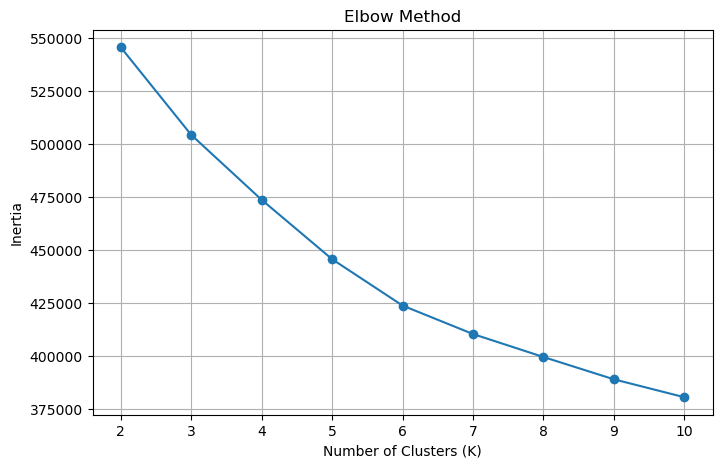

In [30]:
# Plot Elbow Method

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_values)
plt.grid(True)
plt.show()

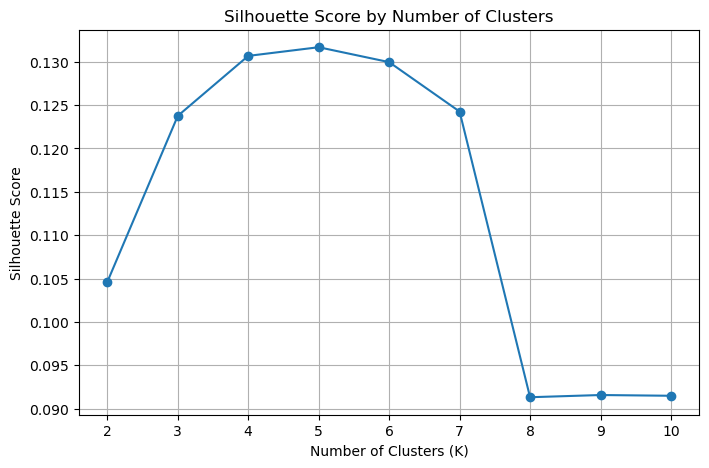

In [31]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [32]:
# Final K-Means model with K=5

kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_sample)

print("K-Means clustering completed!")
print("Number of clusters:", len(set(cluster_labels)))

print("\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means clustering completed!
Number of clusters: 5

Cluster sizes:
0     8877
1    14757
2      989
3     5383
4    19994
Name: count, dtype: int64


In [35]:
# Convert sparse matrix to CSR format for row indexing
X = X.tocsr()

# Create a reproducible sample with original row indices
sample_indices = df_cluster.sample(
    n=50000,
    random_state=42
).index

X_sample = X[sample_indices]
df_sample = df_cluster.loc[sample_indices].copy()

print("Sample shape:", df_sample.shape)
print("Feature matrix shape:", X_sample.shape)

Sample shape: (50000, 18)
Feature matrix shape: (50000, 145)


In [36]:
# Final K-Means clustering on the mapped sample

kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_sample['Cluster'] = kmeans_final.fit_predict(X_sample)

print("Clustering completed!")

print("\nCluster sizes:")
print(df_sample['Cluster'].value_counts().sort_index())

Clustering completed!

Cluster sizes:
Cluster
0     1869
1     9367
2    23075
3     1087
4    14602
Name: count, dtype: int64


In [37]:
# Compare numerical features across clusters

numeric_cluster_features = [
    'Year',
    'Victim Age',
    'Perpetrator Age',
    'Victim Count',
    'Perpetrator Count'
]

cluster_numeric_summary = (
    df_sample
    .groupby('Cluster')[numeric_cluster_features]
    .mean()
    .round(2)
)

print(cluster_numeric_summary)


            Year  Victim Age  Perpetrator Age  Victim Count  Perpetrator Count
Cluster                                                                       
0        1997.84       31.02            23.87          0.14               2.55
1        1996.12       46.79            45.38          0.07               0.05
2        1995.23       27.53            24.79          0.06               0.14
3        1996.94       28.04            30.13          3.06               0.21
4        1996.31       32.91            27.00          0.06               0.03


In [38]:
# Median values by cluster

cluster_numeric_median = (
    df_sample
    .groupby('Cluster')[numeric_cluster_features]
    .median()
    .round(2)
)

print(cluster_numeric_median)

           Year  Victim Age  Perpetrator Age  Victim Count  Perpetrator Count
Cluster                                                                      
0        1997.0        27.0             22.0           0.0                2.0
1        1995.0        44.0             44.0           0.0                0.0
2        1994.0        26.0             24.0           0.0                0.0
3        1997.0        26.0             27.0           2.0                0.0
4        1995.0        30.0             27.0           0.0                0.0


In [39]:
# Crime characteristics by cluster

crime_features = [
    'Crime Type',
    'Crime Solved',
    'Victim Sex',
    'Perpetrator Sex',
    'Relationship',
    'Weapon'
]

for col in crime_features:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    table = pd.crosstab(
        df_sample['Cluster'],
        df_sample[col],
        normalize='index'
    ) * 100

    print(table.round(1))


Crime Type
Crime Type  Manslaughter by Negligence  Murder or Manslaughter
Cluster                                                       
0                                  0.8                    99.2
1                                  1.6                    98.4
2                                  2.2                    97.8
3                                  0.8                    99.2
4                                  0.2                    99.8

Crime Solved
Crime Solved    No    Yes
Cluster                  
0              1.4   98.6
1              0.0  100.0
2              0.0  100.0
3             24.6   75.4
4             99.9    0.1

Victim Sex
Victim Sex  Female  Male  Unknown
Cluster                          
0              9.5  90.4      0.1
1             37.4  62.5      0.1
2             19.8  80.1      0.1
3             42.7  57.3      0.0
4             17.0  82.6      0.4

Perpetrator Sex
Perpetrator Sex  Female  Male  Unknown
Cluster                               
0     

In [40]:
# Geographic and agency characteristics by cluster

location_features = [
    'State',
    'Agency Type',
    'Month'
]

for col in location_features:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    table = pd.crosstab(
        df_sample['Cluster'],
        df_sample[col],
        normalize='index'
    ) * 100

    print(table.round(1))


State
State    Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
Cluster                                                             
0            0.5     0.1      1.4       1.5        16.3       1.3   
1            2.3     0.4      2.2       1.3        12.6       1.3   
2            2.1     0.3      2.1       1.1        14.6       1.2   
3            0.8     0.6      1.7       1.6        13.1       1.6   
4            1.3     0.1      1.9       0.5        19.2       0.7   

State    Connecticut  Delaware  District of Columbia  Florida  ...  \
Cluster                                                        ...   
0                0.3       0.3                   0.1      3.3  ...   
1                0.6       0.2                   0.3      7.3  ...   
2                0.7       0.2                   0.7      5.8  ...   
3                1.0       0.2                   0.2      5.0  ...   
4                0.7       0.1                   2.5      5.7  ...   

State    South Dak

In [41]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Reduce the high-dimensional sparse data to 2 dimensions
svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2d = svd.fit_transform(X_sample)

print("Reduced shape:", X_2d.shape)
print("Explained variance ratio:", svd.explained_variance_ratio_)
print(
    "Total explained variance:",
    svd.explained_variance_ratio_.sum()
)

Reduced shape: (50000, 2)
Explained variance ratio: [0.00683504 0.12581797]
Total explained variance: 0.13265300507691624


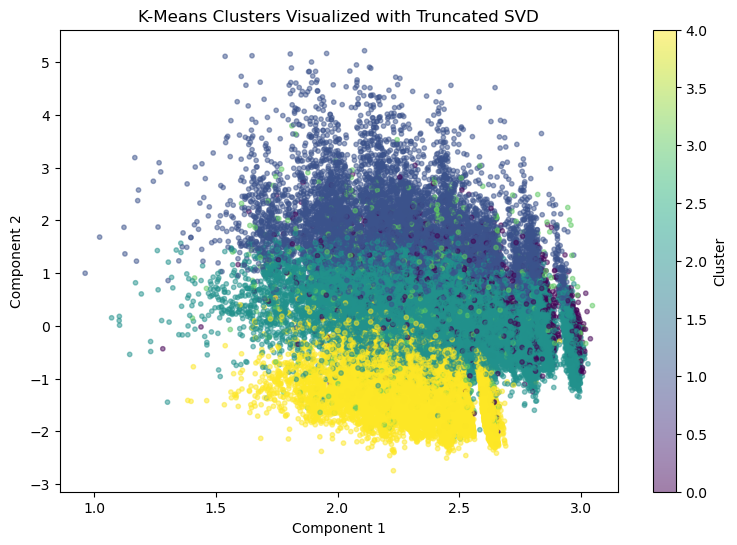

In [42]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df_sample['Cluster'],
    alpha=0.5,
    s=10
)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('K-Means Clusters Visualized with Truncated SVD')
plt.colorbar(scatter, label='Cluster')

plt.show()

In [43]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    X_sample,
    df_sample['Cluster']
)

print(f"Final K=5 Silhouette Score: {final_silhouette:.4f}")

Final K=5 Silhouette Score: 0.1366


K-Means clustering identified five groups with relatively weak separation, as indicated by the final silhouette score of 0.1366. Despite the limited separation, the clusters exhibited differences in crime resolution, demographic characteristics, victim and perpetrator counts, relationships, and weapon types. These results suggest that the dataset contains some underlying grouping patterns, although the clusters should not be interpreted as clearly distinct crime categories.

# Crimes by races

In [44]:
# Count recorded crimes by year and victim race
victim_race_year = pd.crosstab(
    df['Year'],
    df['Victim Race']
)

victim_race_year.head()

Victim Race,Asian/Pacific Islander,Black,Native American/Alaska Native,Unknown,White
Year,,,,,
1980,168,9842,154,658,12270
1981,191,9335,136,134,11412
1982,227,8727,162,91,11337
1983,264,8374,154,92,10769
1984,232,7420,126,136,10179


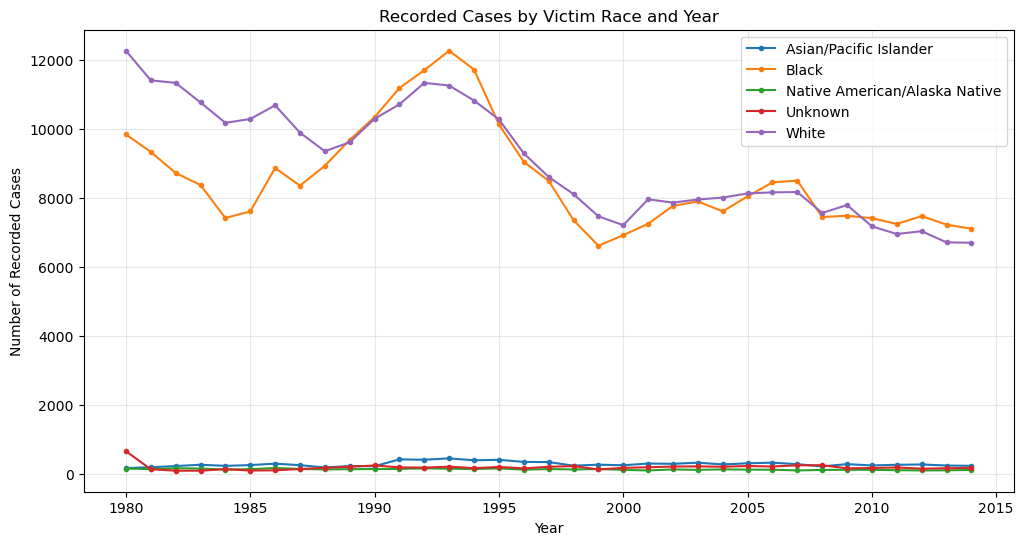

In [46]:
plt.figure(figsize=(12, 6))

for race in victim_race_year.columns:
    plt.plot(
        victim_race_year.index,
        victim_race_year[race],
        marker='o',
        markersize=3,
        label=race
    )

plt.xlabel('Year')
plt.ylabel('Number of Recorded Cases')
plt.title('Recorded Cases by Victim Race and Year')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### The no.1 race each year

In [47]:
top_race_each_year = victim_race_year.idxmax(axis=1)
top_count_each_year = victim_race_year.max(axis=1)

top_race_by_year = pd.DataFrame({
    'Top Victim Race': top_race_each_year,
    'Number of Cases': top_count_each_year
})

top_race_by_year

,Top Victim Race,Number of Cases
Year,,
1980,White,12270
1981,White,11412
1982,White,11337
1983,White,10769
1984,White,10179
1985,White,10290
1986,White,10686
1987,White,9893
1988,White,9355


In [48]:
severity_by_race = df.groupby('Victim Race').agg(
    Total_Cases=('Record ID', 'count'),
    Unsolved_Rate=('Crime Solved', lambda x: (x == 'No').mean() * 100),
    Average_Victim_Count=('Victim Count', 'mean'),
    Multiple_Victim_Rate=('Victim Count', lambda x: (x > 1).mean() * 100)
)

severity_by_race = severity_by_race.sort_values(
    'Total_Cases',
    ascending=False
)

severity_by_race

,Total_Cases,Unsolved_Rate,Average_Victim_Count,Multiple_Victim_Rate
Victim Race,,,,
White,317422,25.907467,0.152970,2.689795
Black,299899,33.719686,0.086979,1.428814
Asian/Pacific Islander,9890,29.494439,0.251871,5.217391
Unknown,6676,46.195327,0.155482,2.890953
Native American/Alaska Native,4567,20.144515,0.125465,2.474272


In [49]:
unsolved_by_race_year = (
    df.assign(
        Unsolved=df['Crime Solved'].eq('No')
    )
    .groupby(['Year', 'Victim Race'])['Unsolved']
    .mean()
    .mul(100)
    .reset_index()
)

unsolved_by_race_year.head()

,Year,Victim Race,Unsolved
0,1980,Asian/Pacific Islander,27.380952
1,1980,Black,24.456411
2,1980,Native American/Alaska Native,25.974026
3,1980,Unknown,45.440729
4,1980,White,29.103504


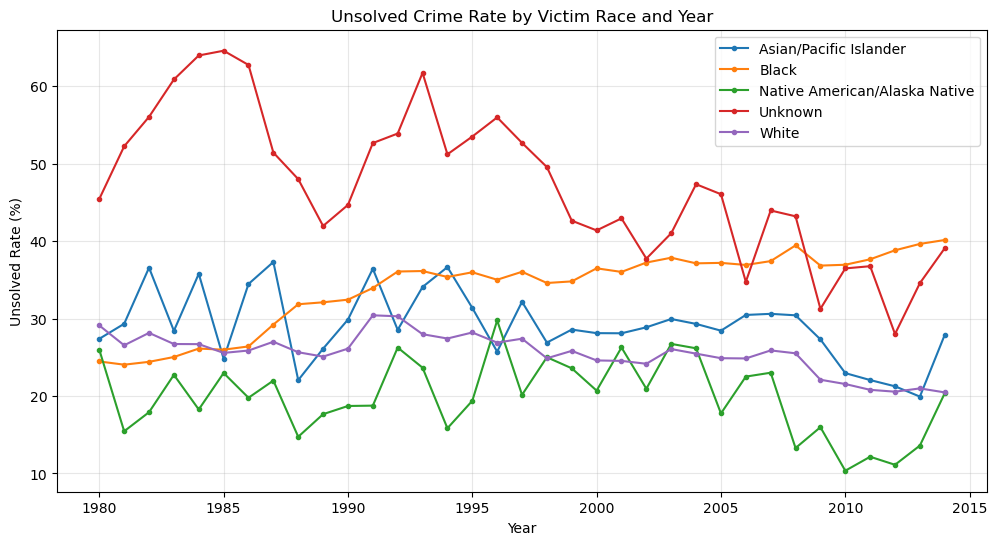

In [50]:
plt.figure(figsize=(12, 6))

for race in unsolved_by_race_year['Victim Race'].unique():
    race_data = unsolved_by_race_year[
        unsolved_by_race_year['Victim Race'] == race
    ]

    plt.plot(
        race_data['Year'],
        race_data['Unsolved'],
        marker='o',
        markersize=3,
        label=race
    )

plt.xlabel('Year')
plt.ylabel('Unsolved Rate (%)')
plt.title('Unsolved Crime Rate by Victim Race and Year')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Race groups were compared using recorded case counts and case characteristics. These results describe the distribution within the dataset and should not be interpreted as population-adjusted crime rates.